In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(35)
n = 1500

df = pd.DataFrame({
    "position": np.random.randint(1, 15, n),
    "avg_consult_mins": np.random.choice([8, 10, 15, 20, 30], n),
    "doctor_speed": np.random.uniform(0.5, 1.5, n),
    "time_of_day": np.random.randint(9, 22, n),
    "day_of_week": np.random.randint(0, 7, n),
})

actual_wait_time = df.position * df.avg_consult_mins 

actual_wait_time += 0.10 * actual_wait_time * ((df.day_of_week == 5) | (df.day_of_week == 6))

# mornings and evenings are busier
actual_wait_time += 0.20 * actual_wait_time* ((df.time_of_day <= 11) | (df.time_of_day >= 19))

# noise
actual_wait_time += np.random.randint(0, 20, n)

# doctor speed
actual_wait_time = actual_wait_time * df.doctor_speed

In [3]:
df["actual_wait_time"] = actual_wait_time

In [4]:
df

,position,avg_consult_mins,doctor_speed,time_of_day,day_of_week,actual_wait_time
0,10,8,0.634869,14,6,64.756685
1,13,10,1.376786,21,6,262.415397
2,8,30,0.903193,9,2,274.570786
3,2,15,0.918932,20,3,39.514092
4,13,30,0.621035,11,1,291.265432
...,...,...,...,...,...,...
1495,14,20,1.433537,12,4,418.592682
1496,3,20,0.878368,19,0,64.120849
1497,2,10,0.749193,9,1,27.720125
1498,7,20,1.485260,20,3,249.523644


In [5]:
df.to_csv('data/simulated_queue.csv')

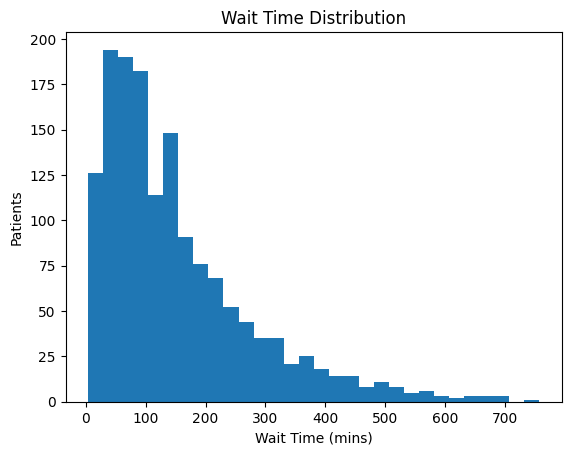

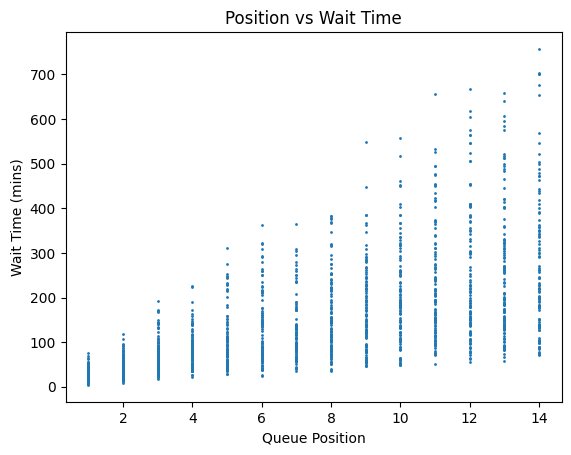

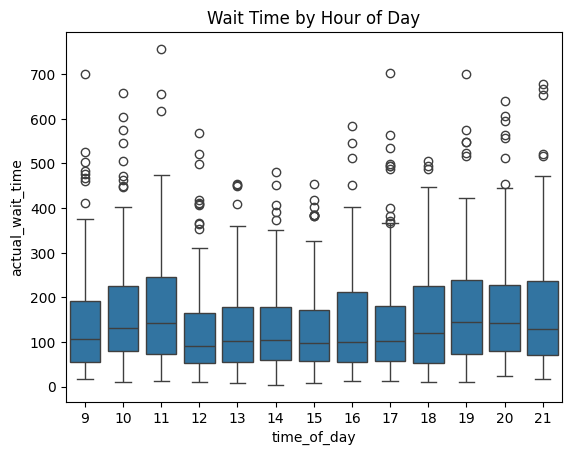

In [6]:
# Plot 1 — wait time distribution
plt.hist(df["actual_wait_time"], bins=30)
plt.title("Wait Time Distribution")
plt.xlabel("Wait Time (mins)")
plt.ylabel("Patients")
plt.show()

# Plot 2 — position vs wait time
plt.scatter(df["position"], df["actual_wait_time"], s=1)
plt.title("Position vs Wait Time")
plt.xlabel("Queue Position")
plt.ylabel("Wait Time (mins)")
plt.show()

# Plot 3 — wait time by hour
sns.boxplot(x=df["time_of_day"], y=df["actual_wait_time"])
plt.title("Wait Time by Hour of Day")
plt.show()